# Analysis of the Scraped Books

### Gameplan

Analysing, Visualising and Investigation of the scraped data

In [1]:
# Imports
import pandas as pd
import numpy as np

# Visualisation
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Loading the data and implementing the scraped csv
books = pd.read_csv("books.toscrape_20251214.csv")

# verifying if all books are stored
print(f'Loaded {len(books)} books.')
books.head()

Loaded 1000 books.


,title,rating,price,available
0,A Light in the Attic,3,51.77,True
1,Tipping the Velvet,1,53.74,True
2,Soumission,1,50.10,True
3,Sharp Objects,4,47.82,True
4,Sapiens: A Brief History of Humankind,5,54.23,True


In [5]:
# checking for missing values & outliers
books.describe()

,rating,price
count,1000.000000,1000.00000
mean,2.923000,35.07035
std,1.434967,14.44669
min,1.000000,10.00000
25%,2.000000,22.10750
50%,3.000000,35.98000
75%,4.000000,47.45750
max,5.000000,59.99000


In [6]:
# finding the most expensive/cheapest book
books.sort_values("price", ascending=False)

,title,rating,price,available
648,The Perfect Play (Play by Play #1),3,59.99,True
617,Last One Home (New Beginnings #1),3,59.98,True
860,Civilization and Its Discontents,2,59.95,True
560,The Barefoot Contessa Cookbook,5,59.92,True
366,The Diary of a Young Girl,3,59.90,True
...,...,...,...,...
302,Greek Mythic History,5,10.23,True
84,Patience,3,10.16,True
716,The Tipping Point: How Little Things Can Make ...,2,10.02,True
501,The Origin of Species,4,10.01,True


In [23]:
# finding the best rated books
books[books['rating'] == 5].sort_values('price', ascending=True)

,title,rating,price,available
638,An Abundance of Katherines,5,10.00,True
302,Greek Mythic History,5,10.23,True
590,The Power Greens Cookbook: 140 Delicious Super...,5,11.05,True
316,Dear Mr. Knightley,5,11.21,True
601,The Darkest Corners,5,11.33,True
...,...,...,...,...
631,Digital Fortress,5,58.00,True
379,How to Speak Golf: An Illustrated Guide to Lin...,5,58.32,True
637,Approval Junkie: Adventures in Caring Too Much,5,58.81,True
812,Life Without a Recipe,5,59.04,True


##### Conclusion:

The cheapest book "An Abundance of Katherines" has also a 5-Star rating, while the most expensive book "The Perfect Play (Play by Play #1)" has only a 3 star rating.

In [25]:
# checking for different prices
prices = books['price'].unique()
print(f'The data contains {len(prices)} different prices!')

# sorting 
prices.sort()
prices

The data contains 903 different prices!


array([10.  , 10.01, 10.02, 10.16, 10.23, 10.27, 10.29, 10.4 , 10.41,
       10.56, 10.6 , 10.62, 10.64, 10.65, 10.66, 10.69, 10.76, 10.79,
       10.9 , 10.92, 10.93, 10.97, 11.05, 11.1 , 11.11, 11.21, 11.23,
       11.33, 11.38, 11.45, 11.48, 11.53, 11.64, 11.68, 11.75, 11.82,
       11.83, 11.84, 11.87, 11.88, 11.89, 12.08, 12.16, 12.23, 12.25,
       12.29, 12.3 , 12.34, 12.36, 12.47, 12.51, 12.55, 12.61, 12.75,
       12.84, 12.86, 12.87, 12.91, 12.96, 13.03, 13.12, 13.2 , 13.22,
       13.33, 13.34, 13.38, 13.47, 13.51, 13.61, 13.66, 13.71, 13.73,
       13.76, 13.82, 13.86, 13.9 , 13.92, 13.99, 14.02, 14.07, 14.08,
       14.1 , 14.16, 14.19, 14.27, 14.36, 14.39, 14.4 , 14.41, 14.44,
       14.54, 14.57, 14.58, 14.64, 14.74, 14.75, 14.76, 14.82, 14.86,
       15.06, 15.08, 15.28, 15.36, 15.38, 15.4 , 15.42, 15.44, 15.48,
       15.52, 15.71, 15.77, 15.79, 15.85, 15.94, 15.97, 16.16, 16.23,
       16.24, 16.26, 16.28, 16.33, 16.34, 16.62, 16.64, 16.68, 16.73,
       16.77, 16.78,

In [26]:
# Grouping books by rating and calculating the average price
books.groupby('rating')['price'].mean()

rating
1    34.561195
2    34.810918
3    34.692020
4    36.093296
5    35.374490
Name: price, dtype: float64

##### Conclusion:
The prices are mathematically randomized and there is no "real-world" relation. => the mean prices per rating are very narrow to each other

In [27]:
# checking if all books are available on the site
books['available'].value_counts()

available
True    1000
Name: count, dtype: int64

##### Conclusion:
All books are available ("in stock") -> no insights from this column

### Visulisation

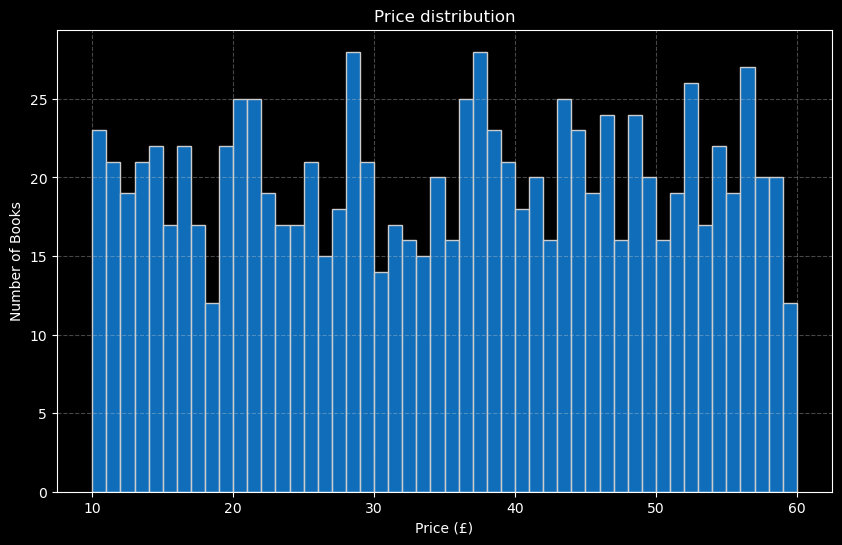

In [93]:
# creating a histplot to see the price distribution
plt.style.use('dark_background')
plt.figure(figsize=(10,6))


ax = sns.histplot(books['price'], 
                  bins=50,
                  color="#1489e9ce",alpha=0.8, edgecolor='#cccccc')

# creating a grid
plt.grid(True,
         color='#cccccc',
         linestyle= '--',
         alpha=0.35)

# labelling
plt.title("Price distribution")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.show()

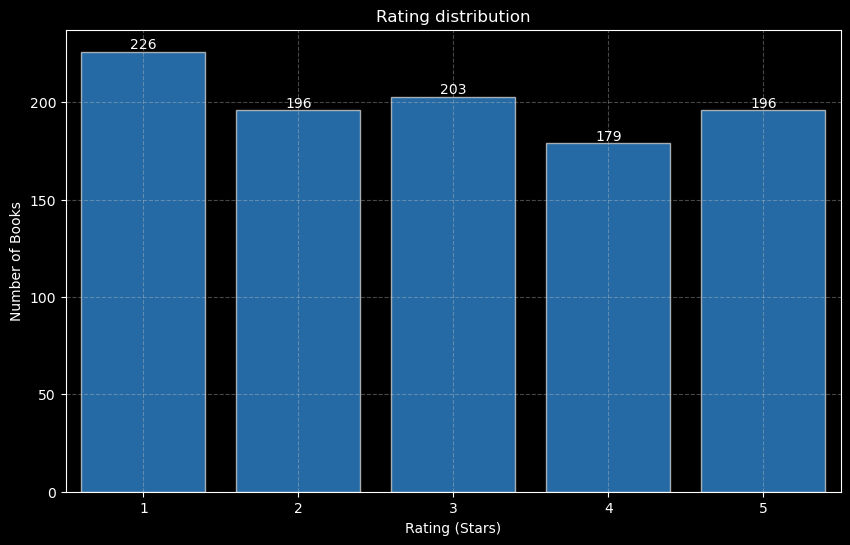

In [92]:
# checking the rating distribution
book_ratings_counted = books.value_counts('rating').reindex([1,2,3,4,5])


# plotting
plt.figure(figsize=(10,6))
ax = sns.countplot(x=books['rating'], color="#1489e9ce",alpha=0.8, edgecolor='#cccccc')

# creating grid
plt.grid(True,
         color='#cccccc',
         linestyle= '--',
         alpha=0.35)

# labeling
plt.title('Rating distribution')
plt.xlabel('Rating (Stars)')
plt.ylabel('Number of Books')

# labeling the bars
for i, value in enumerate(book_ratings_counted):
    plt.text(i, value + 1.5, str(value), ha='center')

plt.show()

#### Conclusion:

No visible distribution in price or rating -> mathematically random generated ratings & prices.

No further analysis or investigation.